# FlexiCT Inference Demo

Minimal single-notebook inference demo for the three pretrained **FlexiCT** models.

## Models

| Model | Input | Output |
|---|---|---|
| `Flexi_CT_2D` | 2D CT slice `[B, 1, H, W]` | CLS token + patch tokens, 864-d |
| `Flexi_CT_3D` | 3D CT volume `[B, 1, D, H, W]` | CLS token + patch tokens, 864-d |
| `Flexi_CT_VLM` | 3D CT volume + text prompts | Image/text embeddings, 1024-d, + similarity scores |

## Notes

Run this notebook in the `flexict` conda environment.

All three models use the same `Flexi_CT_Backbone` architecture:

- ViT-B/16-style backbone
- `embed_dim = 864`
- `patch_size = 8`
- `num_blocks = 16`

Input spatial dimensions must be divisible by `8`.

Use model_2d.backbone.patch_embed_2D.set_patch_size(16) to resample patch size

In [1]:
import numpy as np
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Fill in paths to a real CT slice (2D) and a real CT volume (3D). Leave as None to use synthetic tensors.
SAMPLE_2D_PATH: str | None = None    # e.g. "/path/to/slice.npy" or .png
SAMPLE_3D_PATH: str | None = None    # e.g. "/path/to/volume.nii.gz"

def hu_normalize(x: np.ndarray, lo: float = -1000.0, hi: float = 1000.0) -> np.ndarray:
    """Clamp HU to [lo, hi] and map to [-1, 1]."""
    x = np.clip(x.astype(np.float32), lo, hi)
    return (x - lo) / (hi - lo) * 2.0 - 1.0

## 1. `Flexi_CT_2D` — 2D CT slice backbone

Loads the 2D-pretrained ViT, runs a forward on a single CT slice, and shows output shapes + a PCA-on-patches sanity visualization.

In [ ]:
from flexi_ct import Flexi_CT_2D

model_2d = Flexi_CT_2D(checkpoint_path = '/path/to/2D_final_model.pth', device=DEVICE)
model_2d.eval()
print(f"Params: {sum(p.numel() for p in model_2d.parameters())/1e6:.1f}M")

Params: 144.0M


In [26]:
# --- Build a 2D input from a 3D NIfTI volume --------------------------------

SLICE_SIZE = 256   # must be divisible by patch_size (8)
SAMPLE_2D_PATH = "assets/pancreas_083_0000.nii.gz"

import SimpleITK as sitk

# Load 3D volume: [Z, Y, X]
vol = sitk.GetArrayFromImage(sitk.ReadImage(SAMPLE_2D_PATH)).astype(np.float32)

# Use center axial slice
slice_np = vol[vol.shape[0] // 2]

# Normalize
slice_np = hu_normalize(slice_np)

# Center crop
h, w = slice_np.shape
top = max(0, (h - SLICE_SIZE) // 2)
left = max(0, (w - SLICE_SIZE) // 2)

slice_np = slice_np[top:top + SLICE_SIZE, left:left + SLICE_SIZE]

# Pad if needed
pad_h = SLICE_SIZE - slice_np.shape[0]
pad_w = SLICE_SIZE - slice_np.shape[1]

if pad_h > 0 or pad_w > 0:
    slice_np = np.pad(slice_np, ((0, pad_h), (0, pad_w)))

# Convert to tensor: [B, C, H, W]
x2 = torch.from_numpy(slice_np).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = model_2d(x2)

print(f"cls_token:    {tuple(out['cls_token'].shape)}")
print(
    f"patch_tokens: {tuple(out['patch_tokens'].shape)} "
    f"(expected {(SLICE_SIZE // 8) ** 2} patches)"
)

cls_token:    (1, 864)
patch_tokens: (1, 1024, 864) (expected 1024 patches)


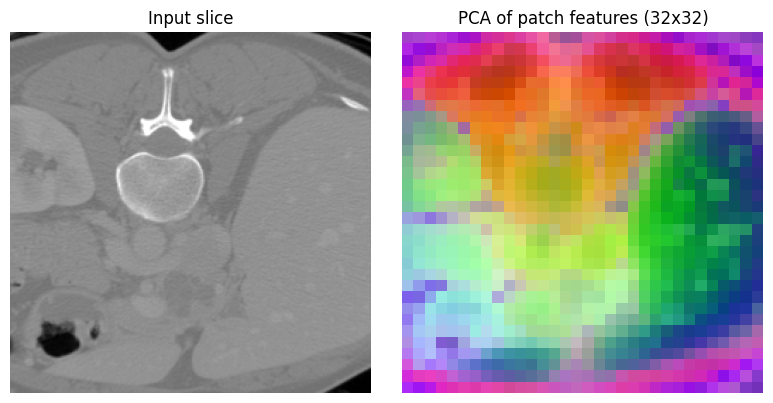

In [27]:
# PCA sanity-visualization: project patch tokens to 3-d RGB and reshape to the patch grid.
import matplotlib.pyplot as plt

g = SLICE_SIZE // 8
tokens = out["patch_tokens"][0].float().cpu().numpy()   # [N, 864]
tokens -= tokens.mean(0, keepdims=True)
_, _, vt = np.linalg.svd(tokens, full_matrices=False)
rgb = tokens @ vt[:3].T
rgb = (rgb - rgb.min(0)) / (rgb.max(0) - rgb.min(0) + 1e-8)
rgb = rgb.reshape(g, g, 3)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(slice_np, cmap="gray"); ax[0].set_title("Input slice"); ax[0].axis("off")
ax[1].imshow(rgb); ax[1].set_title(f"PCA of patch features ({g}x{g})"); ax[1].axis("off")
plt.tight_layout(); plt.show()


## Resampling to larger patch sizes

model_2d.backbone.patch_embed_2D.set_patch_size(16)

model_3d.backbone.patch_embed_3D.set_patch_size(16)

cls_token:    (1, 864)
patch_tokens: (1, 256, 864) (expected 256 patches)


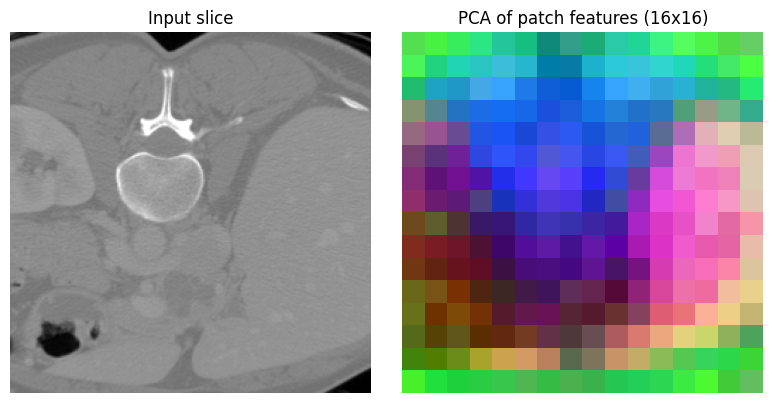

In [30]:
model_2d.backbone.patch_embed_2D.set_patch_size(16)
# Convert to tensor: [B, C, H, W]
x2 = torch.from_numpy(slice_np).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = model_2d(x2)

print(f"cls_token:    {tuple(out['cls_token'].shape)}")
print(
    f"patch_tokens: {tuple(out['patch_tokens'].shape)} "
    f"(expected {(SLICE_SIZE // 16) ** 2} patches)"
)

g = SLICE_SIZE // 16
tokens = out["patch_tokens"][0].float().cpu().numpy()   # [N, 864]
tokens -= tokens.mean(0, keepdims=True)
_, _, vt = np.linalg.svd(tokens, full_matrices=False)
rgb = tokens @ vt[:3].T
rgb = (rgb - rgb.min(0)) / (rgb.max(0) - rgb.min(0) + 1e-8)
rgb = rgb.reshape(g, g, 3)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(slice_np, cmap="gray"); ax[0].set_title("Input slice"); ax[0].axis("off")
ax[1].imshow(rgb); ax[1].set_title(f"PCA of patch features ({g}x{g})"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 2. `Flexi_CT_3D` — 3D CT volume backbone

Loads the 3D-pretrained ViT, runs a forward on a CT volume cropped/padded to `128³`.

In [ ]:
# Free 2D model first — each backbone is ~144M params in fp32.
del model_2d
torch.cuda.empty_cache()

from flexi_ct import Flexi_CT_3D
model_3d = Flexi_CT_3D(checkpoint_path = '/path/to/3D_final_model.pth', device=DEVICE)
model_3d.eval()
print(f"Params: {sum(p.numel() for p in model_3d.parameters())/1e6:.1f}M")

Params: 144.0M


In [14]:
VOL_SIZE = 128
SAMPLE_3D_PATH = "assets/pancreas_083_0000.nii.gz"
TARGET_SPACING = (1.5, 1.5, 1.5)  # spacing is in (X, Y, Z)

import SimpleITK as sitk
import numpy as np
import torch


def resample_to_spacing(img, target_spacing=(1.5, 1.5, 1.5)):
    original_spacing = img.GetSpacing()   # (X, Y, Z)
    original_size = img.GetSize()         # (X, Y, Z)

    new_size = [
        int(round(original_size[i] * original_spacing[i] / target_spacing[i]))
        for i in range(3)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetInterpolator(sitk.sitkLinear)  # use linear for CT/MRI intensities

    return resampler.Execute(img)


def center_crop_or_pad_3d(vol, size):
    out = np.zeros((size, size, size), dtype=vol.dtype)

    src = []
    dst = []

    for dim in vol.shape:
        if dim >= size:
            start = (dim - size) // 2
            src.append(slice(start, start + size))
            dst.append(slice(0, size))
        else:
            start = (size - dim) // 2
            src.append(slice(0, dim))
            dst.append(slice(start, start + dim))

    out[tuple(dst)] = vol[tuple(src)]
    return out


# Load NIfTI as SimpleITK image
img = sitk.ReadImage(SAMPLE_3D_PATH)

# Resample to 1.5 mm isotropic spacing
img = resample_to_spacing(img, TARGET_SPACING)

# Convert to NumPy: [Z, Y, X]
vol_np = sitk.GetArrayFromImage(img).astype(np.float32)

# Normalize and crop/pad to [128, 128, 128]
vol_np = hu_normalize(vol_np)
vol_np = center_crop_or_pad_3d(vol_np, VOL_SIZE)

# Tensor: [B, C, D, H, W]
x3 = torch.from_numpy(vol_np)[None, None].float().to(DEVICE)

with torch.no_grad():
    out = model_3d(x3)

g = VOL_SIZE // 8

print(f"cls_token:    {tuple(out['cls_token'].shape)}")
print(
    f"patch_tokens: {tuple(out['patch_tokens'].shape)} "
    f"(expected {g ** 3} patches = {g}³)"
)

cls_token:    (1, 864)
patch_tokens: (1, 4096, 864) (expected 4096 patches = 16³)


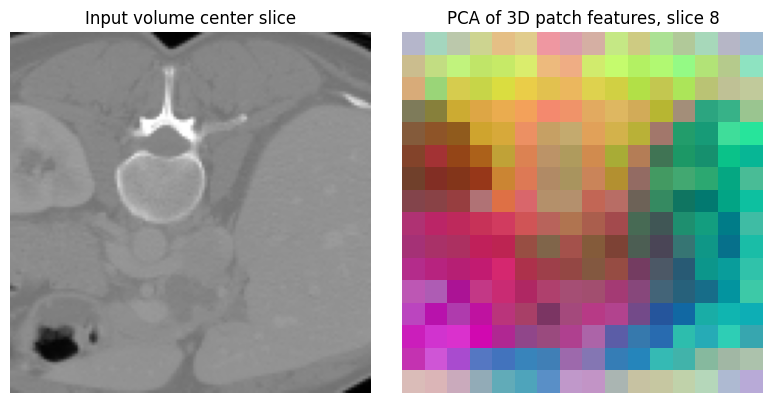

In [15]:
# --- PCA visualization of 3D patch tokens -----------------------------------

PATCH_SIZE = 8
g = VOL_SIZE // PATCH_SIZE

tokens = out['patch_tokens'][0].float().cpu().numpy()   # [N, C]

tokens = tokens - tokens.mean(axis=0, keepdims=True)

_, _, vt = np.linalg.svd(tokens, full_matrices=False)

rgb = tokens @ vt[:3].T
rgb = (rgb - rgb.min(axis=0)) / (rgb.max(axis=0) - rgb.min(axis=0) + 1e-8)

rgb = rgb.reshape(g, g, g, 3)   # [D, H, W, 3]

mid = g // 2

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(vol_np[VOL_SIZE // 2], cmap="gray")
ax[0].set_title("Input volume center slice")
ax[0].axis("off")

ax[1].imshow(rgb[mid])
ax[1].set_title(f"PCA of 3D patch features, slice {mid}")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## 3. `Flexi_CT_VLM` — CT image-text zero-shot

Loads the CT vision-language model (Flexi CT vision tower + Qwen3-Embedding-0.6B text tower, joint 1024-d space). Computes cosine similarity between a CT volume and a small set of text prompts.

In [ ]:
del model_3d
torch.cuda.empty_cache()

from flexi_ct import Flexi_CT_VLM
vlm = Flexi_CT_VLM(checkpoint_path = '/path/to/3D_VLM_final_model.pth', device=DEVICE)
vlm.eval()
print(f"Params: {sum(p.numel() for p in vlm.parameters())/1e6:.1f}M")

Params: 741.5M


In [24]:
# Reuse the 3D volume prepared above (x3). If this cell is run standalone, re-run section 2's input cell first.
prompts = [
    "Chest",
    "Abdominal",
    "Pelvis",
    "Head and neck",
]

with torch.no_grad():
    img_emb = vlm.encode_image(x3)
    txt_emb = vlm.encode_text(prompts)
    sim = vlm.similarity(img_emb, txt_emb)             # [1, N_prompts]
    probs = sim.softmax(dim=-1).cpu().numpy()[0]

print(f"img_emb: {tuple(img_emb.shape)}")
print(f"txt_emb: {tuple(txt_emb.shape)}")
print("similarity (softmax over prompts):")
for p, s in zip(prompts, probs):
    print(f"  {s:6.3f}  {p}")

img_emb: (1, 1024)
txt_emb: (4, 1024)
similarity (softmax over prompts):
   0.112  Chest
   0.346  Abdominal
   0.348  Pelvis
   0.194  Head and neck
